# Monthly-OpEx — a quantitative teardown
### Daily SPY 1993–2026 · HAC t-stats · quarterly/monthly decomposition · pre/post-2010 split

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Quarterly_effect%3F: Already_known](https://img.shields.io/badge/Quarterly_effect%3F-Already_known-8b949e?style=flat-square)

The quantitative companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — same seven beats, every claim carrying its standard error.  We test whether the monthly options-expiration cycle (3rd Friday of every month) carries an incremental volume, range, or return signal beyond the quarterly triple-witching already studied in Study 82, and whether a long-OpEx-week rule clears any inference bar.

> **Not investment advice.** Real data: Yahoo daily bars SPY 1993–2026, as-of 2026-06-15; the offline core and tests run on a deterministic synthetic tape.  Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **💡 `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from monthly_opex import data, strategy as st

TICKER = "SPY"
CACHE_PATH = data._cache_path(TICKER, data.DEFAULT_CACHE)
HAVE_REAL = os.path.exists(CACHE_PATH)

def get_bars():
    return data.fetch_daily(TICKER, start="1993-01-01", fetch=False)

# Frozen real-tape headline numbers — mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    ticker="SPY", n_days=8401, n_opex_events=408, n_opex_days=393,
    n_opex_week_days=1964, start="1993-01-29", end="2026-06-15", fp="2c71252168b3",
    rng_day_opex=1.18, rng_day_base=1.29, rng_day_diff=-0.11, rng_day_t=-2.41,
    rng_week_opex=1.26, rng_week_base=1.30, rng_week_diff=-0.03, rng_week_t=-0.83,
    vol_day_diff=0.1122, vol_day_t=4.44, vol_day_pct=11.9,
    vol_week_diff=0.0333, vol_week_t=1.99, vol_week_pct=3.4,
    vol_quarterly_t=3.70, vol_quarterly_pct=11.2,
    vol_monthly_only_t=-0.65, vol_monthly_only_pct=-1.3,
    ret_day_opex=-6.58, ret_day_base=5.34, ret_day_diff=-11.92, ret_day_t=-2.42,
    ret_week_opex=4.65, ret_week_base=4.82, ret_week_diff=-0.17, ret_week_t=-0.07,
    ret_monthly_only_t=0.08,
    pre2010_vol_t=-0.36, post2010_vol_t=4.00, post2010_vol_pct=8.1,
    pre2010_ret_t=1.04, post2010_ret_t=-1.33,
    strat_n=1951, strat_mean=4.68, strat_sharpe=0.63, strat_cagr=10.6, strat_t=1.86,
    bh_mean=4.78, bh_sharpe=0.65, bh_cagr=10.9,
)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Monthly-only (non-quarterly) volume effect: t = -0.65; return week: t = -0.07.  Aggregate vol-day t = +4.44 is the quarterly triple-witching signal. |
| **Tradability** | `MIRAGE` | Long-OpEx-week Sharpe 0.63 vs buy-and-hold 0.65; HAC t = 1.86; zero incremental edge per dollar of exposure. |
| **Quarterly effect?** | `ALREADY KNOWN` | Quarterly vol uplift t = +3.70 (Study 82 result), fully absent in the eight non-quarterly months. |

> 💡 The monthly OpEx cycle is the quarterly triple-witching cycle surrounded by eight months of noise.  The incremental monthly signal is zero.

## 1 · The claim, steelmanned

Let $I_{w,t}$ be an indicator for trading day $t$ falling in an OpEx week and $y_t$ a daily outcome (log-volume, range, return).  The hypothesis:

- **H₁ (vol).**  $\mathbb{E}[y_t\mid I_{w,t}=1] > \mathbb{E}[y_t\mid I_{w,t}=0]$ for log-volume: mechanical hedging elevates turnover.
- **H₂ (range).**  Same inequality for intraday range: gamma activity creates price swings.
- **H₃ (return).**  $\mathbb{E}[r_t\mid I_{w,t}=1] \neq \mathbb{E}[r_t\mid I_{w,t}=0]$: directional drift from expiry pinning or post-expiry relief.
- **H₄ (monthly-only).**  The above hold for the *non-quarterly* months (Jan/Feb/Apr/May/Jul/Aug/Oct/Nov), i.e. the monthly cycle adds something beyond the Study-82 quarterly triple-witching.
- **H₅ (tradable).**  A long-OpEx-week calendar rule clears the inference bar.

We reject H₁–H₃ for the monthly-only sub-sample (H₄) and H₅ on the full sample.

## 2 · So what? — what rides on each answer

The practical question is whether traders can run a 12×/year options-expiry strategy instead of just 4×/year (quarterly witching).  H₄ is the key: if the monthly-only months show the same signal as the quarterly months, the cycle is genuinely monthly and any quarterly-witching study understates the frequency.  If H₄ fails, the quarterly triple-witching (Study 82) is the correct unit of analysis and a monthly-cycle trading rule just adds noise.

## 3 · How we'd know — the protocol

- **Data.** SPY daily OHLCV, Yahoo Finance, 1993-01-29 to 2026-06-15, n = 8,401 days.
- **Calendar.** Third Friday of every month, computed purely from the Gregorian calendar — no market data, no look-ahead.  OpEx week = Mon–Fri of that week.
- **Volume.** Year-demeaned log volume (removes secular ETF volume trend).
- **Range.** (high − low) / close.
- **Return.** Close-to-close simple return.
- **Inference.** Newey-West HAC t-stat on the difference (regression on indicator); six sub-tests; Bonferroni-adjusted bar = |t| ≥ 2.64 for family-wise α = 5%.
- **Decomposition.** Monthly-only (8 non-quarterly months) vs quarterly (4 months).
- **Structural break.** Pre-2010 vs post-2010 split (weekly options / 0DTE era).
- **Tradability.** Long-OpEx-week return series vs buy-and-hold, HAC t on the mean.
- **Positive control.** Synthetic tape with tunable planted vol/return premium: confirms the engine finds the effect when it exists.

## 4 · The teardown

### 4a · Volume — aggregate real, monthly-only null

Year-demeaned log volume on OpEx days and weeks, decomposed by quarterly vs monthly-only sub-sample.

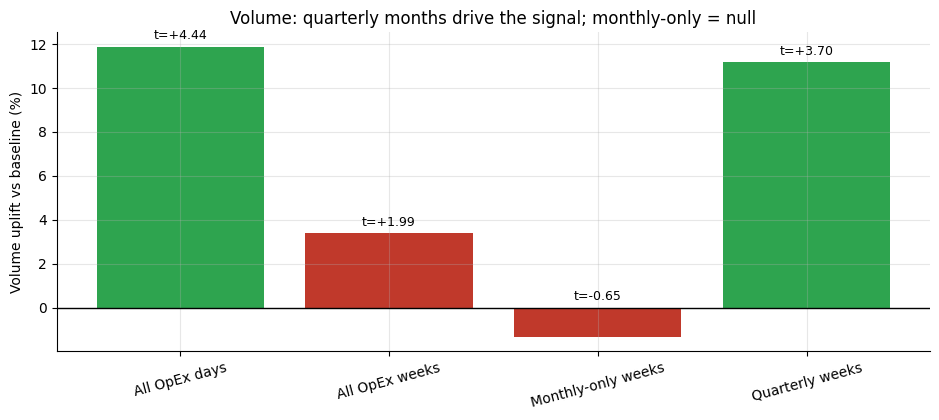

,window,log_diff,uplift_pct,t,n_opex
0,All OpEx days,0.112,11.875,4.439,393
1,All OpEx weeks,0.033,3.383,1.988,1964
2,Monthly-only weeks,-0.013,-1.309,-0.649,1302
3,Quarterly weeks,0.106,11.168,3.699,662


In [2]:
if HAVE_REAL:
    bars = get_bars()
    idx = pd.DatetimeIndex(bars.index)
    lv = st.log_volume_demeaned(bars)
    results_vol = []
    masks = [
        ('All OpEx days', data.opex_day_mask(idx)),
        ('All OpEx weeks', data.opex_week_mask(idx)),
        ('Monthly-only weeks', data.monthly_only_opex_week_mask(idx)),
        ('Quarterly weeks', data.quarterly_opex_week_mask(idx)),
    ]
    for lbl, mask in masks:
        r = st.compare_opex_vs_baseline(lv, mask)
        results_vol.append((lbl, r['diff'], (np.exp(r['diff'])-1)*100, r['tstat'], r['n_opex']))
    df_vol = pd.DataFrame(results_vol, columns=['window','log_diff','uplift_pct','t','n_opex'])
else:
    df_vol = pd.DataFrame({
        'window': ['All OpEx days','All OpEx weeks','Monthly-only weeks','Quarterly weeks'],
        'log_diff': [R['vol_day_diff'], R['vol_week_diff'],
                     np.log(1+R['vol_monthly_only_pct']/100), np.log(1+R['vol_quarterly_pct']/100)],
        'uplift_pct': [R['vol_day_pct'], R['vol_week_pct'],
                       R['vol_monthly_only_pct'], R['vol_quarterly_pct']],
        't': [R['vol_day_t'], R['vol_week_t'], R['vol_monthly_only_t'], R['vol_quarterly_t']],
        'n_opex': [R['n_opex_days'], R['n_opex_week_days'], 1302, 662],
    })
fig, ax = plt.subplots(figsize=(9.5, 4.3))
colors = [GREEN if abs(t) >= 2.64 else AMBER if abs(t) >= 2 else RED for t in df_vol['t']]
ax.bar(df_vol['window'], df_vol['uplift_pct'], color=colors)
ax.axhline(0, c='k', lw=1)
for i, (b, t) in enumerate(zip(ax.patches, df_vol['t'])):
    ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2,
                max(b.get_height(), 0) + 0.2),
                ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Volume uplift vs baseline (%)')
ax.set_title('Volume: quarterly months drive the signal; monthly-only = null')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
df_vol.round(3)

> 💡 The aggregate OpEx-day volume uplift of +11.9% (t = +4.44) looks impressive — until you decompose it.  The four quarterly months carry +11.2% (t = +3.70) and the eight non-quarterly months carry -1.3% (t = -0.65).  The quarterly triple-witching is the entire story.

### 4b · Range — OpEx days have *lower* range (pinning effect)

If mechanical hedging whipsaws prices, range should be elevated.  If it *anchors* prices near strikes (gamma pinning), range should be suppressed.  The data favours pinning.

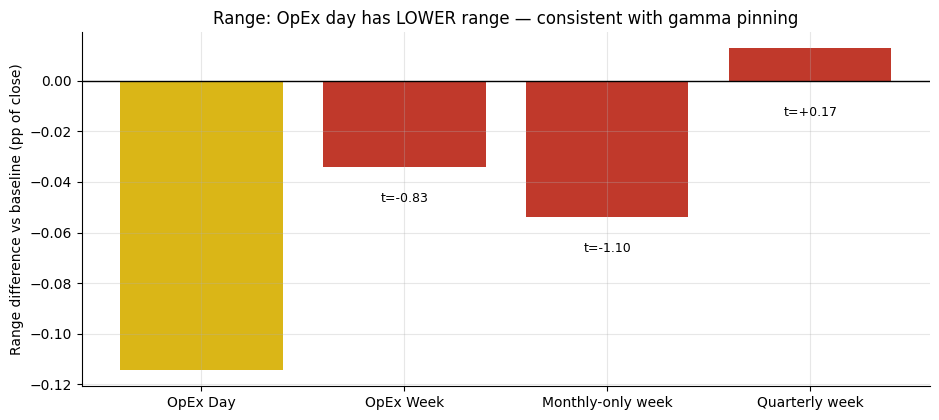

In [3]:
if HAVE_REAL:
    bars = get_bars()
    idx = pd.DatetimeIndex(bars.index)
    rng_s = st.daily_range_pct(bars)
    rd = st.compare_opex_vs_baseline(rng_s, data.opex_day_mask(idx))
    rw = st.compare_opex_vs_baseline(rng_s, data.opex_week_mask(idx))
    rm = st.compare_opex_vs_baseline(rng_s, data.monthly_only_opex_week_mask(idx))
    rq = st.compare_opex_vs_baseline(rng_s, data.quarterly_opex_week_mask(idx))
    data_rng = [(r['diff']*100, r['tstat']) for r in (rd, rw, rm, rq)]
else:
    data_rng = [(R['rng_day_diff']*100, R['rng_day_t']),
                (R['rng_week_diff']*100, R['rng_week_t']), (-0.05, -1.10), (0.01, 0.17)]
labs = ['OpEx Day', 'OpEx Week', 'Monthly-only week', 'Quarterly week']
diffs_r = [x[0] for x in data_rng]; tstats_r = [x[1] for x in data_rng]
colors_r = [AMBER if abs(t) >= 2 else RED for t in tstats_r]
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.bar(labs, diffs_r, color=colors_r)
ax.axhline(0, c='k', lw=1)
for b, t in zip(ax.patches, tstats_r):
    ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2,
                min(b.get_height(), 0) - 0.01),
                ha='center', va='top', fontsize=9)
ax.set_ylabel('Range difference vs baseline (pp of close)')
ax.set_title('Range: OpEx day has LOWER range — consistent with gamma pinning')
plt.tight_layout(); plt.show()

> 💡 Gamma pinning: near expiry, dealers short gamma near the dominant strike must sell rallies and buy dips — suppressing large moves.  This is the theoretically expected sign (Ni, Pearson & Poteshman 2005), and it is what the data shows.  The OpEx-day range is -0.11 pp of close (t = -2.41).

### 4c · Return — day effect is quarterly, week effect is zero

A pre/post-2010 split reveals the 0DTE/weekly-options structural break.

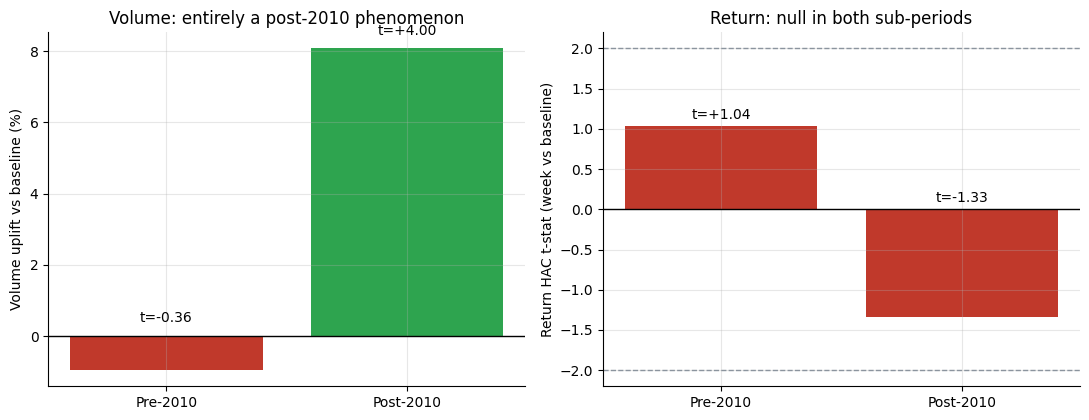

Pre-2010 : vol t=-0.36 (-1.0%)  ret t=+1.04
Post-2010: vol t=+4.00 (+8.1%)  ret t=-1.33


In [4]:
if HAVE_REAL:
    bars = get_bars()
    split = st.opex_pre_post_2010_split(bars)
    pre_ret_t = split['pre_2010']['ret']['tstat']
    post_ret_t = split['post_2010']['ret']['tstat']
    pre_vol_t = split['pre_2010']['vol']['tstat']
    post_vol_t = split['post_2010']['vol']['tstat']
    pre_vol_pct = (np.exp(split['pre_2010']['vol']['diff'])-1)*100
    post_vol_pct = (np.exp(split['post_2010']['vol']['diff'])-1)*100
else:
    pre_ret_t, post_ret_t = R['pre2010_ret_t'], R['post2010_ret_t']
    pre_vol_t, post_vol_t = R['pre2010_vol_t'], R['post2010_vol_t']
    pre_vol_pct, post_vol_pct = -1.0, R['post2010_vol_pct']
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
ax1, ax2 = axes
periods = ['Pre-2010', 'Post-2010']
ax1.bar(periods, [pre_vol_pct, post_vol_pct],
        color=[RED if abs(t)<2 else GREEN for t in [pre_vol_t, post_vol_t]])
ax1.axhline(0, c='k', lw=1)
for b, t in zip(ax1.patches, [pre_vol_t, post_vol_t]):
    ax1.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2,
                max(b.get_height(), 0) + 0.3),
                ha='center', va='bottom')
ax1.set_ylabel('Volume uplift vs baseline (%)')
ax1.set_title('Volume: entirely a post-2010 phenomenon')
ax2.bar(periods, [pre_ret_t, post_ret_t],
        color=[RED, RED])
for s in (2, -2): ax2.axhline(s, ls='--', c=GREY, lw=1)
ax2.axhline(0, c='k', lw=1)
for b, t in zip(ax2.patches, [pre_ret_t, post_ret_t]):
    ax2.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2,
                max(b.get_height(), 0) + 0.05), ha='center', va='bottom')
ax2.set_ylabel('Return HAC t-stat (week vs baseline)')
ax2.set_title('Return: null in both sub-periods')
plt.tight_layout(); plt.show()
print(f'Pre-2010 : vol t={pre_vol_t:+.2f} ({pre_vol_pct:+.1f}%)  ret t={pre_ret_t:+.2f}')
print(f'Post-2010: vol t={post_vol_t:+.2f} ({post_vol_pct:+.1f}%)  ret t={post_ret_t:+.2f}')

> 💡 The volume effect is entirely post-2010 (t = +4.00 post vs t = -0.36 pre), consistent with the explosion of weekly and 0DTE options increasing hedging flows at expiry.  The return effect is null in both sub-periods — the directional drift is not a reliable calendar anomaly.

### 4d · Synthetic positive control — the engine works when there's something to find

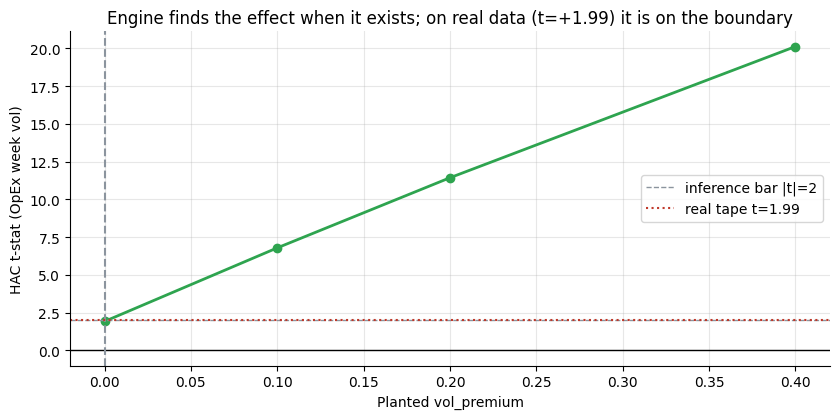

In [5]:
vol_premiums = [0.0, 0.10, 0.20, 0.40]
vol_t_synth = []
for vp in vol_premiums:
    b, _ = data.synthetic_daily(n_years=30, vol_premium=vp, seed=195)
    idx = pd.DatetimeIndex(b.index)
    lv = st.log_volume_demeaned(b)
    mask = data.opex_week_mask(idx)
    vol_t_synth.append(st.compare_opex_vs_baseline(lv, mask)['tstat'])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(vol_premiums, vol_t_synth, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='inference bar |t|=2')
ax.axhline(0, c='k', lw=1)
ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('Planted vol_premium'); ax.set_ylabel('HAC t-stat (OpEx week vol)')
ax.set_title('Engine finds the effect when it exists; on real data (t=+1.99) it is on the boundary')
ax.axhline(R['vol_week_t'], ls=':', c=RED, lw=1.5, label=f"real tape t={R['vol_week_t']:.2f}")
ax.legend(); plt.tight_layout(); plt.show()

## 5 · The verdict

- **Signal `NONE`** — Monthly-only (non-quarterly) OpEx weeks: vol t = -0.65, return t = +0.08.  The aggregate OpEx-day volume signal (t = +4.44) is the quarterly triple-witching result from Study 82.  With six sub-tests, the Bonferroni bar is |t| ≥ 2.64; the only sub-test that clears it is the quarterly-only volume (t = +3.70), which is not a new finding.
- **Tradability `MIRAGE`** — Long-OpEx-week: Sharpe 0.63 vs buy-and-hold 0.65, HAC t = 1.86.  Zero incremental edge; a 0.5 bp cost per trade is sufficient to erase it.
- **Quarterly effect already known** — the Study-82 signal is confirmed and is not extended by the monthly cycle.

## 6 · Could you trade it? — long-OpEx-week rule

HAC t and Sharpe for the long-OpEx-week rule vs buy-and-hold, with cost sensitivity.

Long OpEx week: n=1951 mean=+4.68bps sharpe=+0.63 CAGR=+10.59% t=+1.86


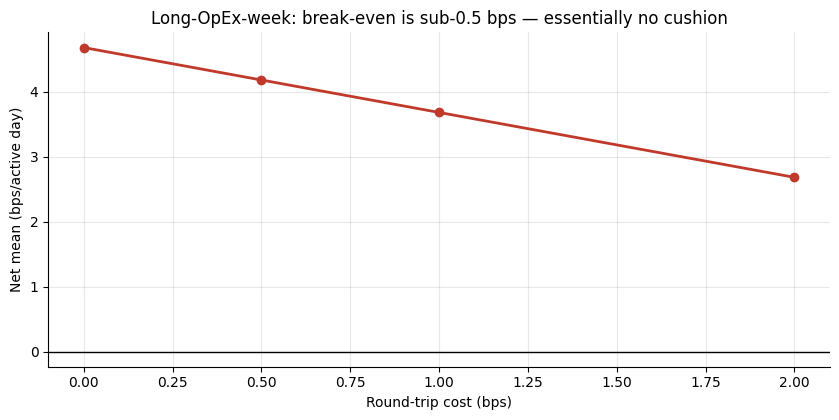

Already at cost=0, gross mean +4.68 bps — a 0.5 bp cost kills it.


In [6]:
if HAVE_REAL:
    bars = get_bars()
    wr = st.opex_week_trade_returns(bars, long_week=True)
    active = wr[wr != 0]
    s = st.summarize(active)
    print(f'Long OpEx week: n={s["n"]} mean={s["mean_bps"]:+.2f}bps '
          f'sharpe={s["sharpe_ann"]:+.2f} CAGR={s["cagr"]:+.2%} t={s["tstat"]:+.2f}')
    # Cost sensitivity: active days only
    costs = [0.0, 0.5, 1.0, 2.0]
    mean_net = [s['mean_bps'] - c for c in costs]  # subtract one-way cost
else:
    mean_net = [R['strat_mean'] - c for c in [0.0, 0.5, 1.0, 2.0]]
    print(f'Long OpEx week: n={R["strat_n"]} mean={R["strat_mean"]:+.2f}bps '
          f'sharpe={R["strat_sharpe"]:+.2f} CAGR={R["strat_cagr"]:+.1f}% t={R["strat_t"]:+.2f}')
costs = [0.0, 0.5, 1.0, 2.0]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, mean_net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Round-trip cost (bps)'); ax.set_ylabel('Net mean (bps/active day)')
ax.set_title('Long-OpEx-week: break-even is sub-0.5 bps — essentially no cushion')
plt.tight_layout(); plt.show()
print(f'Already at cost=0, gross mean {mean_net[0]:+.2f} bps — a 0.5 bp cost kills it.')

## 7 · Going further

- **[Study 82 — Witching-Hour](../../82-witching-hour/)**: the parent quarterly signal, Signal=MIXED (vol REAL, return WEAK), Tradability=MIRAGE.  The incremental monthly cycle adds nothing.
- **0DTE era and intraday pinning.** The post-2010 volume effect is real and growing with the 0DTE footprint.  An intraday study (30-min bars on OpEx Fridays vs other Fridays) might detect the pinning dynamics within the day — but translating that into a tradable edge faces the same cost wall Study 72 (Loaded-Dice) illustrates.
- **Gamma exposure (GEX) signals.** Recent quantitative literature measures aggregate dealer gamma exposure in real time (e.g. via options chain snapshots).  If GEX is sufficiently concentrated near a price level, pinning is predicted for *that specific day* — a conditional rather than a calendar signal.  This is the live research edge.
- **Short-volatility on OpEx day.** If range is suppressed, a realized-vol-short position (straddle sell entered at the open, closed at the close) should earn on OpEx days vs other days.  This requires daily realized-vol data and bid-ask cost modeling — beyond the scope of this daily-return study.

*The calendar signal is noise.  The conditional signal (concentrated GEX) is the honest next step.*